# Deep Reinforcement Learning Tutorial: DQN and Decision Transformer

1. **Deep Q-Network (DQN):** learns online by interacting with `CartPole-v1`.
2. **Decision Transformer (DT):** learns offline from saved CartPole trajectories.


## Setup


```python
state, info = env.reset()
next_state, reward, terminated, truncated, info = env.step(action)
```

`terminated` means the task reached a terminal state. `truncated` usually means an external limit, such as the 500-step CartPole time limit.



In [13]:
# Install only packages that are missing from the current Python environment.
# This makes the cell fast in Colab and other preconfigured notebook systems.
import importlib.util
import subprocess
import sys

required = {
    "gymnasium": "gymnasium[classic-control]>=1.1,<2",
    "torch": "torch>=2.2",
    "matplotlib": "matplotlib>=3.8",
    "numpy": "numpy>=1.26",
}
missing = [
    package
    for module, package in required.items()
    if importlib.util.find_spec(module) is None
]

if missing:
    print("Installing:", missing)
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
else:
    print("All required packages are available.")

All required packages are available.


In [14]:
# Core imports and reproducibility settings
import copy
import math
import random
from collections import deque, namedtuple

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

SEED = 7
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Use a GPU when one is available. These examples also run on a CPU.
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Gymnasium:", gym.__version__)
print("PyTorch:", torch.__version__)
print("Device:", DEVICE)

Gymnasium: 1.3.0
PyTorch: 2.13.0+cu126
Device: cuda


## 1. Inspect the environment

`CartPole-v1` has a four-dimensional continuous observation:

$$
s_t = [x_t,\ \dot{x}_t,\ \theta_t,\ \dot{\theta}_t].
$$

Here, $x_t$ is the cart position and $\theta_t$ is the pole angle. Dots denote their velocities.

It has two discrete actions: push left or push right. The agent receives `+1` for every step that the pole remains balanced.



In [15]:
ENV_NAME = "CartPole-v1"
env = gym.make(ENV_NAME)

state, info = env.reset(seed=SEED)
print("Initial state:", state)
print("Observation shape:", env.observation_space.shape)
print("Action space:", env.action_space)

random_return = 0.0
done = False
while not done:
    action = env.action_space.sample()
    state, reward, terminated, truncated, info = env.step(action)
    random_return += reward
    done = terminated or truncated

print("One random-policy return:", random_return)
env.close()

Initial state: [ 0.01250955  0.03972138  0.02756857 -0.02747928]
Observation shape: (4,)
Action space: Discrete(2)
One random-policy return: 31.0


# Part A — Deep Q-Network

For a transition $(s_t,a_t,r_{t+1},s_{t+1},d_t)$, DQN uses the target

$$
y_t = r_{t+1} + \gamma(1-d_t)\max_{a'} Q_{\mathrm{target}}(s_{t+1},a').
$$

The online network predicts $Q_{\mathrm{online}}(s_t,a_t)$. We minimise a TD loss between the target and prediction.

DQN adds two stabilisers to neural Q-learning:

- **Replay memory:** random minibatches reduce temporal correlation.
- **Target network:** a slowly updated copy makes the bootstrap target more stable.

## 2. Q-network

The network receives one state and returns one Q-value for each action.



In [16]:
class QNetwork(nn.Module):
    def __init__(self, state_dim, action_dim, hidden_dim=128):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, action_dim),
        )

    def forward(self, states):
        # Input shape:  [batch_size, state_dim]
        # Output shape: [batch_size, action_dim]
        return self.network(states)


demo_env = gym.make(ENV_NAME)
STATE_DIM = demo_env.observation_space.shape[0]
ACTION_DIM = demo_env.action_space.n
demo_env.close()

q_demo = QNetwork(STATE_DIM, ACTION_DIM).to(DEVICE)
sample_states = torch.zeros(3, STATE_DIM, device=DEVICE)
print("Input shape:", sample_states.shape)
print("Q-value shape:", q_demo(sample_states).shape)

Input shape: torch.Size([3, 4])
Q-value shape: torch.Size([3, 2])


## 3. Replay memory

The replay memory stores old transitions. Random sampling mixes experience from different times and episodes.



In [17]:
Transition = namedtuple(
    "Transition", ["state", "action", "reward", "next_state", "done"]
)


class ReplayBuffer:
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)

    def add(self, state, action, reward, next_state, done):
        self.buffer.append(
            Transition(
                np.asarray(state, dtype=np.float32),
                int(action),
                float(reward),
                np.asarray(next_state, dtype=np.float32),
                float(done),
            )
        )

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states = torch.as_tensor(np.stack([x.state for x in batch]), device=DEVICE)
        actions = torch.as_tensor(
            [x.action for x in batch], dtype=torch.long, device=DEVICE
        )
        rewards = torch.as_tensor(
            [x.reward for x in batch], dtype=torch.float32, device=DEVICE
        )
        next_states = torch.as_tensor(
            np.stack([x.next_state for x in batch]), device=DEVICE
        )
        dones = torch.as_tensor(
            [x.done for x in batch], dtype=torch.float32, device=DEVICE
        )
        return states, actions, rewards, next_states, dones

    def __len__(self):
        return len(self.buffer)

## 4. Exploration and one DQN update

An epsilon-greedy policy explores with probability $\epsilon$ and acts greedily otherwise. Epsilon will decrease during training.



In [18]:
def select_dqn_action(q_network, state, epsilon, action_dim):
    # Explore with a uniformly random action.
    if random.random() < epsilon:
        return random.randrange(action_dim)

    # Exploit by choosing the largest predicted Q-value.
    state_tensor = torch.as_tensor(state, dtype=torch.float32, device=DEVICE).unsqueeze(
        0
    )
    with torch.no_grad():
        return int(q_network(state_tensor).argmax(dim=1).item())


def dqn_update(online_net, target_net, replay, optimizer, batch_size, gamma):
    states, actions, rewards, next_states, dones = replay.sample(batch_size)

    # Select Q_online(s, a) for the action stored in each transition.
    all_q_values = online_net(states)
    chosen_q_values = all_q_values.gather(1, actions.unsqueeze(1)).squeeze(1)

    # Build a stable TD target with the separate target network.
    with torch.no_grad():
        next_q_values = target_net(next_states).max(dim=1).values
        td_targets = rewards + gamma * (1.0 - dones) * next_q_values

    # Huber loss is less sensitive to large TD errors than squared error.
    loss = F.smooth_l1_loss(chosen_q_values, td_targets)

    optimizer.zero_grad()
    loss.backward()
    nn.utils.clip_grad_norm_(online_net.parameters(), max_norm=10.0)
    optimizer.step()
    return float(loss.item())

## 5. Train DQN

The loop alternates between data collection and minibatch updates. Every fixed number of environment steps, it copies the online weights into the target network.



In [6]:
def train_dqn(
    env_name,
    seed=SEED,
    max_episodes=400,
    gamma=0.99,
    learning_rate=5e-4,
    batch_size=64,
    replay_capacity=50_000,
    learning_starts=1_000,
    target_update_every=500,
    epsilon_start=1.0,
    epsilon_end=0.03,
    epsilon_decay=0.990,
):
    env = gym.make(env_name)
    state_dim = env.observation_space.shape[0]
    action_dim = env.action_space.n

    online_net = QNetwork(state_dim, action_dim).to(DEVICE)
    target_net = copy.deepcopy(online_net).to(DEVICE)
    target_net.eval()

    optimizer = torch.optim.Adam(online_net.parameters(), lr=learning_rate)
    replay = ReplayBuffer(replay_capacity)

    returns, losses = [], []
    epsilon = epsilon_start
    total_steps = 0
    best_mean = -np.inf
    best_weights = copy.deepcopy(online_net.state_dict())

    for episode in range(max_episodes):
        state, _ = env.reset(seed=seed + episode)
        episode_return = 0.0
        done = False

        while not done:
            action = select_dqn_action(online_net, state, epsilon, action_dim)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            replay.add(state, action, reward, next_state, done)
            state = next_state
            episode_return += reward
            total_steps += 1

            # Start learning only after the buffer contains varied experience.
            if len(replay) >= max(learning_starts, batch_size):
                loss = dqn_update(
                    online_net, target_net, replay, optimizer, batch_size, gamma
                )
                losses.append(loss)

            # Hard target update: copy online parameters every C steps.
            if total_steps % target_update_every == 0:
                target_net.load_state_dict(online_net.state_dict())

        returns.append(episode_return)
        epsilon = max(epsilon_end, epsilon * epsilon_decay)

        moving_average = np.mean(returns[-20:])
        # Keep the strongest checkpoint because value learning can fluctuate.
        if len(returns) >= 20 and moving_average > best_mean:
            best_mean = moving_average
            best_weights = copy.deepcopy(online_net.state_dict())
        if (episode + 1) % 25 == 0:
            print(
                f"Episode {episode + 1:3d} | "
                f"20-episode mean {moving_average:6.1f} | epsilon {epsilon:.3f}"
            )

        # CartPole-v1 is capped at 500. Stop after consistent strong performance.
        if episode >= 75 and moving_average >= 475.0:
            print(
                f"Early stop at episode {episode + 1}: mean return {moving_average:.1f}"
            )
            break

    env.close()
    online_net.load_state_dict(best_weights)
    print(f"Restored best checkpoint with 20-episode mean {best_mean:.1f}")
    return online_net, {"returns": returns, "losses": losses}


dqn, dqn_history = train_dqn(ENV_NAME)

Episode  25 | 20-episode mean   18.4 | epsilon 0.778
Episode  50 | 20-episode mean   16.0 | epsilon 0.605
Episode  75 | 20-episode mean   15.0 | epsilon 0.471
Episode 100 | 20-episode mean   13.9 | epsilon 0.366
Episode 125 | 20-episode mean   12.2 | epsilon 0.285
Episode 150 | 20-episode mean   19.4 | epsilon 0.221
Episode 175 | 20-episode mean  133.2 | epsilon 0.172
Episode 200 | 20-episode mean  196.2 | epsilon 0.134
Episode 225 | 20-episode mean  136.4 | epsilon 0.104
Episode 250 | 20-episode mean  123.4 | epsilon 0.081
Episode 275 | 20-episode mean  110.0 | epsilon 0.063
Episode 300 | 20-episode mean  117.2 | epsilon 0.049
Episode 325 | 20-episode mean  151.4 | epsilon 0.038
Episode 350 | 20-episode mean  156.8 | epsilon 0.030
Episode 375 | 20-episode mean  182.5 | epsilon 0.030
Episode 400 | 20-episode mean  147.8 | epsilon 0.030
Restored best checkpoint with 20-episode mean 218.0


## 6. Evaluate and visualise DQN

Evaluation sets epsilon to zero. This separates the learned greedy policy from training-time exploration.

Evaluation returns: [232 190 230 167 183 222 212 197 204 210]
Mean ± SD: 204.7 ± 19.8


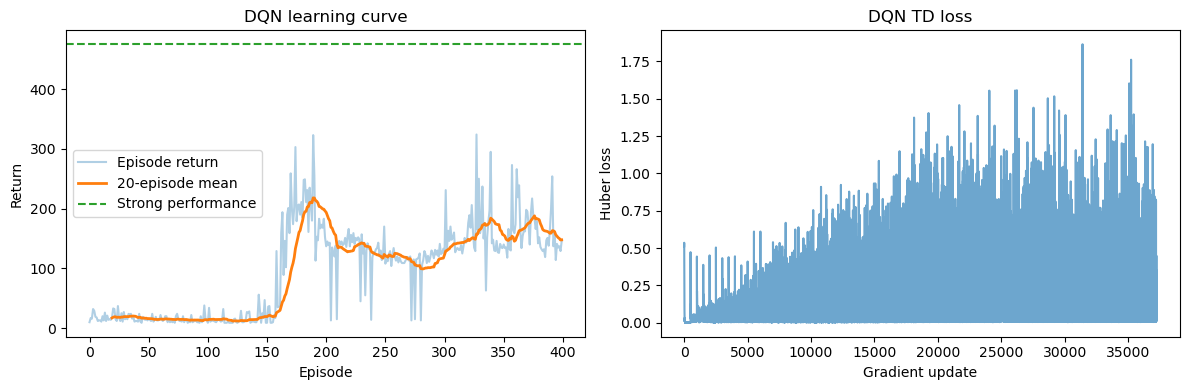

In [7]:
def evaluate_dqn(q_network, env_name, episodes=10, seed=10_000):
    env = gym.make(env_name)
    action_dim = env.action_space.n
    returns = []

    for episode in range(episodes):
        state, _ = env.reset(seed=seed + episode)
        done = False
        total_reward = 0.0
        while not done:
            action = select_dqn_action(
                q_network, state, epsilon=0.0, action_dim=action_dim
            )
            state, reward, terminated, truncated, _ = env.step(action)
            total_reward += reward
            done = terminated or truncated
        returns.append(total_reward)

    env.close()
    return np.asarray(returns, dtype=np.float32)


dqn_eval_returns = evaluate_dqn(dqn, ENV_NAME)
print("Evaluation returns:", dqn_eval_returns.astype(int))
print(f"Mean ± SD: {dqn_eval_returns.mean():.1f} ± {dqn_eval_returns.std():.1f}")

window = 20
moving = np.convolve(dqn_history["returns"], np.ones(window) / window, mode="valid")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(dqn_history["returns"], alpha=0.35, label="Episode return")
axes[0].plot(
    np.arange(window - 1, len(dqn_history["returns"])),
    moving,
    linewidth=2,
    label=f"{window}-episode mean",
)
axes[0].axhline(475, color="tab:green", linestyle="--", label="Strong performance")
axes[0].set(xlabel="Episode", ylabel="Return", title="DQN learning curve")
axes[0].legend()

axes[1].plot(dqn_history["losses"], alpha=0.65)
axes[1].set(xlabel="Gradient update", ylabel="Huber loss", title="DQN TD loss")
plt.tight_layout()
plt.show()

# Part B — Decision Transformer

DQN learned while acting. Decision Transformer uses a fixed dataset:

$$
\mathcal{D}=\{\tau^{(1)},\ldots,\tau^{(N)}\}.
$$

For each trajectory, compute the undiscounted return-to-go

$$
G_t=\sum_{k=t}^{T}r_{k+1}.
$$

Then represent each timestep with three tokens:

$$
(G_1,s_1,a_1,G_2,s_2,a_2,\ldots,G_T,s_T,a_T).
$$

A causal Transformer predicts $a_t$ from the desired return and available history. It uses cross-entropy because CartPole has discrete actions.



## 7. Build a mixed-quality offline dataset

We use the trained DQN as a data generator only. Different epsilon values create expert-like, noisy, and random trajectories. After collection, DT never asks the behaviour policy for new training data.



Number of trajectories: 210
Number of transitions: 26839
Return percentiles [0, 25, 50, 75, 100]: [ 10  32 139 201 421]


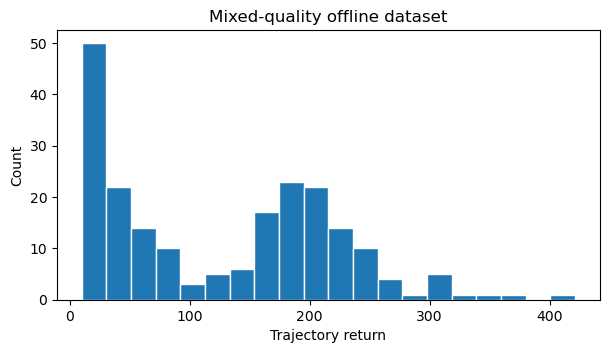

In [19]:
def compute_returns_to_go(rewards):
    # Reverse cumulative sum: [r1+r2+...+rT, r2+...+rT, ..., rT]
    rewards = np.asarray(rewards, dtype=np.float32)
    return np.cumsum(rewards[::-1])[::-1].copy()


def collect_offline_trajectories(
    q_network,
    env_name,
    epsilons=(0.0, 0.05, 0.15, 0.30, 0.50, 0.80, 1.0),
    episodes_per_epsilon=30,
    seed=20_000,
):
    env = gym.make(env_name)
    action_dim = env.action_space.n
    trajectories = []

    episode_id = 0
    for epsilon in epsilons:
        for _ in range(episodes_per_epsilon):
            state, _ = env.reset(seed=seed + episode_id)
            states, actions, rewards = [], [], []
            done = False

            while not done:
                action = select_dqn_action(q_network, state, epsilon, action_dim)
                states.append(np.asarray(state, dtype=np.float32))
                actions.append(action)

                state, reward, terminated, truncated, _ = env.step(action)
                rewards.append(float(reward))
                done = terminated or truncated

            trajectories.append(
                {
                    "states": np.asarray(states, dtype=np.float32),
                    "actions": np.asarray(actions, dtype=np.int64),
                    "rewards": np.asarray(rewards, dtype=np.float32),
                    "returns_to_go": compute_returns_to_go(rewards),
                    "epsilon": epsilon,
                }
            )
            episode_id += 1

    env.close()
    return trajectories


trajectories = collect_offline_trajectories(dqn, ENV_NAME)
trajectory_returns = np.asarray([x["rewards"].sum() for x in trajectories])
all_states = np.concatenate([x["states"] for x in trajectories], axis=0)
STATE_MEAN = all_states.mean(axis=0)
STATE_STD = all_states.std(axis=0) + 1e-6
RETURN_SCALE = 500.0

print("Number of trajectories:", len(trajectories))
print("Number of transitions:", sum(len(x["actions"]) for x in trajectories))
print(
    "Return percentiles [0, 25, 50, 75, 100]:",
    np.percentile(trajectory_returns, [0, 25, 50, 75, 100]).astype(int),
)

plt.figure(figsize=(7, 3.5))
plt.hist(trajectory_returns, bins=20, edgecolor="white")
plt.xlabel("Trajectory return")
plt.ylabel("Count")
plt.title("Mixed-quality offline dataset")
plt.show()

## 8. Create padded trajectory subsequences

The Transformer trains on windows of at most `CONTEXT_LEN` timesteps. Short sequences are padded. A mask prevents padded positions from contributing to the loss.



In [20]:
CONTEXT_LEN = 20
MAX_TIMESTEP = 500


def sample_dt_batch(trajectories, batch_size, context_len=CONTEXT_LEN):
    batch_states = np.zeros((batch_size, context_len, STATE_DIM), np.float32)
    batch_actions = np.zeros((batch_size, context_len), np.int64)
    batch_returns = np.zeros((batch_size, context_len, 1), np.float32)
    batch_timesteps = np.zeros((batch_size, context_len), np.int64)
    batch_mask = np.zeros((batch_size, context_len), bool)

    for i in range(batch_size):
        trajectory = random.choice(trajectories)
        length = len(trajectory["actions"])
        start = random.randrange(length)
        end = min(start + context_len, length)
        valid = end - start

        states = trajectory["states"][start:end]
        batch_states[i, :valid] = (states - STATE_MEAN) / STATE_STD
        batch_actions[i, :valid] = trajectory["actions"][start:end]
        batch_returns[i, :valid, 0] = (
            trajectory["returns_to_go"][start:end] / RETURN_SCALE
        )
        batch_timesteps[i, :valid] = np.arange(start, end).clip(0, MAX_TIMESTEP - 1)
        batch_mask[i, :valid] = True

    return (
        torch.as_tensor(batch_returns, device=DEVICE),
        torch.as_tensor(batch_states, device=DEVICE),
        torch.as_tensor(batch_actions, device=DEVICE),
        torch.as_tensor(batch_timesteps, device=DEVICE),
        torch.as_tensor(batch_mask, device=DEVICE),
    )


example_batch = sample_dt_batch(trajectories, batch_size=3)
names = ["returns", "states", "actions", "timesteps", "valid mask"]
for name, tensor in zip(names, example_batch):
    print(f"{name:10s}: {tuple(tensor.shape)}")
print("First mask:", example_batch[-1][0].cpu().numpy().astype(int))

returns   : (3, 20, 1)
states    : (3, 20, 4)
actions   : (3, 20)
timesteps : (3, 20)
valid mask: (3, 20)
First mask: [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


In [25]:
example_batch[3]

tensor([[147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160,
         161, 162, 163, 164, 165, 166],
        [ 57,  58,  59,  60,  61,  62,  63,  64,  65,  66,  67,  68,  69,  70,
          71,  72,  73,  74,  75,  76],
        [  2,   3,   4,   5,   6,   7,   8,   9,  10,  11,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0]], device='cuda:0')

## 9. Decision Transformer model

Return, state, and action have different raw forms. Separate learned layers map them to the same embedding size. A timestep embedding tells the model where each triple occurs.

The causal mask blocks every token from attending to future tokens. The action head reads the output at each **state-token position**.



In [10]:
class DecisionTransformer(nn.Module):
    def __init__(
        self,
        state_dim,
        action_dim,
        embed_dim=64,
        n_heads=4,
        n_layers=2,
        dropout=0.1,
        max_timestep=MAX_TIMESTEP,
    ):
        super().__init__()
        self.return_embedding = nn.Linear(1, embed_dim)
        self.state_embedding = nn.Linear(state_dim, embed_dim)
        self.action_embedding = nn.Embedding(action_dim, embed_dim)
        self.timestep_embedding = nn.Embedding(max_timestep, embed_dim)
        self.token_type_embedding = nn.Embedding(3, embed_dim)

        layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=n_heads,
            dim_feedforward=4 * embed_dim,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True,
        )
        self.transformer = nn.TransformerEncoder(layer, num_layers=n_layers)
        self.final_norm = nn.LayerNorm(embed_dim)
        self.action_head = nn.Linear(embed_dim, action_dim)

    def forward(self, returns_to_go, states, actions, timesteps, valid_mask):
        batch_size, sequence_len = actions.shape
        time = self.timestep_embedding(timesteps)

        # Each modality gets its own projection plus time and token-type information.
        return_tokens = self.return_embedding(returns_to_go) + time
        state_tokens = self.state_embedding(states) + time
        action_tokens = self.action_embedding(actions) + time
        return_tokens += self.token_type_embedding.weight[0]
        state_tokens += self.token_type_embedding.weight[1]
        action_tokens += self.token_type_embedding.weight[2]

        # Interleave as (R_1, S_1, A_1, R_2, S_2, A_2, ...).
        tokens = torch.stack(
            (return_tokens, state_tokens, action_tokens), dim=2
        ).reshape(batch_size, 3 * sequence_len, -1)

        # True values above the diagonal block attention to future tokens.
        token_count = tokens.shape[1]
        causal_mask = torch.triu(
            torch.ones(
                token_count, token_count, dtype=torch.bool, device=tokens.device
            ),
            diagonal=1,
        )

        # Repeat the timestep mask for its return, state, and action tokens.
        token_valid = (
            valid_mask.unsqueeze(-1).expand(-1, -1, 3).reshape(batch_size, token_count)
        )

        hidden = self.transformer(
            tokens,
            mask=causal_mask,
            src_key_padding_mask=~token_valid,
        )
        hidden = self.final_norm(hidden)

        # Positions 1, 4, 7, ... are state-token positions.
        state_hidden = hidden[:, 1::3, :]
        return self.action_head(state_hidden)


dt_demo = DecisionTransformer(STATE_DIM, ACTION_DIM).to(DEVICE)
with torch.no_grad():
    demo_logits = dt_demo(*example_batch)
print("Action-logit shape:", tuple(demo_logits.shape))

Action-logit shape: (3, 20, 2)


/tmp/ipykernel_380717/982456882.py:28: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(layer, num_layers=n_layers)


## 10. Train Decision Transformer offline

The loss is cross-entropy over valid action targets. There is no environment interaction, replay target, or Bellman backup in this loop.



/tmp/ipykernel_380717/982456882.py:28: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(layer, num_layers=n_layers)


Update  100 | mean recent loss 0.6664
Update  200 | mean recent loss 0.6291
Update  300 | mean recent loss 0.6002
Update  400 | mean recent loss 0.5682
Update  500 | mean recent loss 0.5481
Update  600 | mean recent loss 0.5318


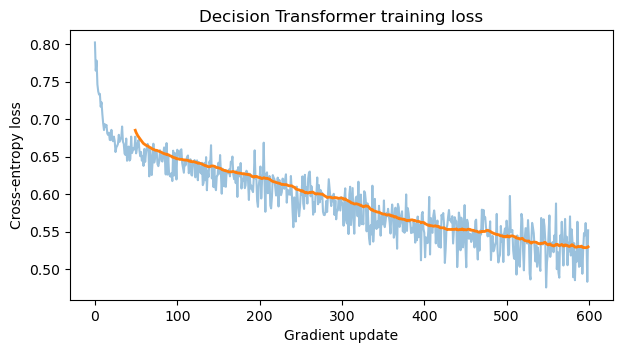

In [11]:
def train_decision_transformer(
    trajectories,
    state_dim,
    action_dim,
    updates=600,
    batch_size=64,
    learning_rate=3e-4,
):
    model = DecisionTransformer(state_dim, action_dim).to(DEVICE)
    optimizer = torch.optim.AdamW(
        model.parameters(), lr=learning_rate, weight_decay=1e-4
    )
    losses = []

    model.train()
    for update in range(1, updates + 1):
        returns, states, actions, timesteps, valid_mask = sample_dt_batch(
            trajectories, batch_size
        )
        logits = model(returns, states, actions, timesteps, valid_mask)

        # Ignore padded timesteps in the supervised action-prediction loss.
        loss = F.cross_entropy(logits[valid_mask], actions[valid_mask])

        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        losses.append(float(loss.item()))

        if update % 100 == 0:
            print(f"Update {update:4d} | mean recent loss {np.mean(losses[-100:]):.4f}")

    return model, losses


decision_transformer, dt_losses = train_decision_transformer(
    trajectories, STATE_DIM, ACTION_DIM
)

plt.figure(figsize=(7, 3.5))
plt.plot(dt_losses, alpha=0.45)
smooth = np.convolve(dt_losses, np.ones(50) / 50, mode="valid")
plt.plot(np.arange(49, len(dt_losses)), smooth, linewidth=2)
plt.xlabel("Gradient update")
plt.ylabel("Cross-entropy loss")
plt.title("Decision Transformer training loss")
plt.show()

## 11. Return-conditioned DT inference

At the beginning, choose a desired return that exists in the dataset. After receiving reward $r_{t+1}$, update the remaining target:

$$
G^{\mathrm{target}}_{t+1}=G^{\mathrm{target}}_t-r_{t+1}.
$$

Only the most recent `CONTEXT_LEN` timesteps are retained.



In [12]:
def evaluate_decision_transformer(
    model,
    env_name,
    target_return,
    episodes=5,
    context_len=CONTEXT_LEN,
    seed=30_000,
):
    env = gym.make(env_name)
    episode_returns = []
    model.eval()

    for episode in range(episodes):
        state, _ = env.reset(seed=seed + episode)
        states = [np.asarray(state, dtype=np.float32)]
        actions = []
        desired_returns = [float(target_return)]
        done = False
        total_reward = 0.0
        t = 0

        while not done:
            # Keep only the most recent context window.
            context_states = states[-context_len:]
            length = len(context_states)
            context_actions = actions[-(length - 1) :] if length > 1 else []
            context_returns = desired_returns[-length:]
            first_timestep = t - length + 1

            states_array = np.zeros((1, context_len, STATE_DIM), np.float32)
            actions_array = np.zeros((1, context_len), np.int64)
            returns_array = np.zeros((1, context_len, 1), np.float32)
            timesteps_array = np.zeros((1, context_len), np.int64)
            mask_array = np.zeros((1, context_len), bool)

            states_array[0, :length] = (
                np.asarray(context_states) - STATE_MEAN
            ) / STATE_STD
            if context_actions:
                actions_array[0, : length - 1] = np.asarray(context_actions)
            returns_array[0, :length, 0] = np.asarray(context_returns) / RETURN_SCALE
            timesteps_array[0, :length] = np.arange(first_timestep, t + 1).clip(
                0, MAX_TIMESTEP - 1
            )
            mask_array[0, :length] = True

            batch = tuple(
                torch.as_tensor(x, device=DEVICE)
                for x in (
                    returns_array,
                    states_array,
                    actions_array,
                    timesteps_array,
                    mask_array,
                )
            )
            with torch.no_grad():
                logits = model(*batch)
                action = int(logits[0, length - 1].argmax().item())

            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            total_reward += reward
            actions.append(action)

            if not done:
                states.append(np.asarray(next_state, dtype=np.float32))
                desired_returns.append(desired_returns[-1] - reward)
            t += 1

        episode_returns.append(total_reward)

    env.close()
    return np.asarray(episode_returns, dtype=np.float32)


target_returns = np.percentile(trajectory_returns, [25, 50, 90])
dt_results = {}
for target in target_returns:
    returns = evaluate_decision_transformer(
        decision_transformer, ENV_NAME, target_return=float(target)
    )
    dt_results[int(target)] = returns
    print(
        f"Target {target:6.1f} -> achieved mean {returns.mean():6.1f} | {returns.astype(int)}"
    )

Target   29.2 -> achieved mean  144.8 | [205 130 173 109 107]
Target  135.0 -> achieved mean  216.8 | [191 206 295 204 188]
Target  237.6 -> achieved mean  245.8 | [232 308 258 220 211]
